# Indefiniteness of the segment Hamiltonian $A$ — an interactive exploration

**Companion notebook to Epsilon_study_2 §7.12** (*Local-vs-cooperative indefiniteness of A — the hub breakdown behind the classical efficiency cliff*). §7.12 gives the full, rigorous treatment with the production $(\sigma_{\rm res},T)$ grid; this notebook is the hands-on version — every claim is something you can re-run and plot here.

## The puzzle

At $\sigma_{\rm res}=0.05$ mm the **classical** segment efficiency is pinned at $\sim1.0$ up to $T\approx400$ and then **breaks**: 0.984 @ T=200, 0.98 @ 400, 0.909 @ 700, 0.786 @ 1000 (qtrk store, absolute $\tau=0.35$). The false-rate story cannot explain a loss of *true* segments. And the efficiency-first search of §7.10 bottomed out at $\tau=0.061$ — the true-segment **amplitudes themselves fall below $\tau$ and go negative**. So this is not a threshold problem; it is a **solver** problem, and it is spectral.

## The order parameter

The segment Hamiltonian is

$$A = (\gamma+\delta)\,I - C,\qquad A x = \delta\,\mathbf 1,$$

with $C$ the kink-acceptance coupling — an **adjacency matrix** ($C_{ij}=1$ when segments $i,j$ share a hit and their kink is below $\varepsilon$; zero diagonal). Because the diagonal of $A$ is the *constant* $\gamma+\delta$,

$$\lambda(A) = (\gamma+\delta) - \lambda(C)\quad\Longrightarrow\quad \lambda_{\min}(A) = (\gamma+\delta) - \lambda_{\max}(C),$$

so

> **$A$ is indefinite $\iff \lambda_{\max}(C) > \gamma+\delta$**  (= 4 at the production $\gamma=3,\,\delta=1$).

Everything below is a statement about $\lambda_{\max}(C)$.

In [1]:
import sys
sys.path.insert(0, "../_shared")
sys.path.insert(0, "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src")
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.csgraph import connected_components
from collections import defaultdict
import matplotlib.pyplot as plt
%matplotlib inline

import helpers
from lhcb_velo_toy.analysis import compute_epsilon
from lhcb_velo_toy.analysis.segment_metrics import segment_truth_mask
from lhcb_velo_toy.solvers import SimpleHamiltonianFast
from lhcb_velo_toy.generation import StateEventGenerator

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
from pathlib import Path
FIG = Path(".").resolve() / "figures" / "indefiniteness"
FIG.mkdir(parents=True, exist_ok=True)

GAMMA, DELTA = helpers.GAMMA, helpers.DELTA      # 3, 1
GD = GAMMA + DELTA                                # 4  -> threshold (gamma+delta)^2 = 16
TAU = 0.35
GEOM = helpers.make_geometry()
print(f"gamma={GAMMA}, delta={DELTA}, gamma+delta={GD}, (gamma+delta)^2={GD**2}, tau={TAU}")

gamma=3.0, delta=1.0, gamma+delta=4.0, (gamma+delta)^2=16.0, tau=0.35


### Reproducible event generation — a gotcha worth knowing

`helpers.safe_generate` calls `np.random.seed(seed)`, but `StateEventGenerator`
builds its **own** `np.random.default_rng()` and *ignores* the global seed — so the
same seed gives a **different** event every call. For a reproducible study we inject a
seeded generator directly (`gen.rng = np.random.default_rng(seed)`). This affects every
toy study that relies on `safe_generate` seeds.

In [2]:
def gen_event(T, sigma_res, sigma_scatt, seed):
    '''Reproducible event: seed the generator's own rng directly.'''
    last = None
    for k in range(20):
        g = StateEventGenerator(detector_geometry=GEOM, events=1, n_particles=[T],
                                phi_min=-0.2, phi_max=0.2, theta_min=-0.2, theta_max=0.2,
                                measurement_error=sigma_res, collision_noise=sigma_scatt)
        g.rng = np.random.default_rng(int(seed) + k)
        g.generate_random_primary_vertices(helpers.PV_SIGMA)
        g.generate_particles([[{"type": "pion", "mass": 139.6, "q": 1}] * T])
        ev = g.generate_complete_events(); last = ev
        if ev.tracks and min(len(t.hit_ids) for t in ev.tracks) >= 3:
            return ev
    return last

def build_A(T, sigma_res, sigma_scatt, seed, eps=None, ev=None):
    '''Build the segment Hamiltonian; return (ham, A_csr, C_csr, eps, ev). No solve.'''
    if eps is None:
        eps = float(compute_epsilon(sigma_res, sigma_scatt))
    if ev is None:
        ev = gen_event(T, sigma_res, sigma_scatt, seed)
    ham = SimpleHamiltonianFast(epsilon=eps, gamma=GAMMA, delta=DELTA, theta_d=1e-4)
    ham.construct_segments(ev, materialize_segments=False)
    ham.construct_hamiltonian(ev, convolution=False)
    A = ham.A.tocsr()
    C = (sp.identity(A.shape[0], format="csr") * GD - A); C.eliminate_zeros()
    return ham, A, C, eps, ev

# sanity: same seed -> identical matrix
_, A1, *_ = build_A(120, 0.05, 1e-4, seed=7)
_, A2, *_ = build_A(120, 0.05, 1e-4, seed=7)
print("reproducible:", A1.nnz == A2.nnz and (A1 != A2).nnz == 0)

reproducible: True


## 1. The idealised hub — a complete bipartite block (closed form)

`construct_hamiltonian` couples two segments only when they **share a middle hit**
and the kink between them is $<\varepsilon$. As we confirm in §2, the pair is always an
**in**-segment (ending at the hit) and an **out**-segment (starting at it) — never two of
the same side. So the local block at a hub is a **bipartite** graph $K(m_{\rm in},m_{\rm out})$.

For a *complete* such block, $A x = \delta\mathbf 1$ has a clean closed form (all in-nodes
share $x_{\rm in}$, all out-nodes share $x_{\rm out}$ by symmetry):

$$x_{\rm in}=\frac{(\gamma+\delta)+m_{\rm out}}{(\gamma+\delta)^2-m_{\rm in}m_{\rm out}},\quad
x_{\rm out}=\frac{(\gamma+\delta)+m_{\rm in}}{(\gamma+\delta)^2-m_{\rm in}m_{\rm out}},\quad
\lambda_{\min}(A)=(\gamma+\delta)-\sqrt{m_{\rm in}m_{\rm out}}.$$

The **star** $K(1,m)$ is the $m_{\rm in}=1$ case: $x_c=(4+m)/(16-m)$, $x_\ell=5/(16-m)$.
The amplitudes **diverge** at the product $(\gamma+\delta)^2=16$ and **flip sign** beyond it —
that is a true segment being driven negative. The critical product $(\gamma+\delta)^2$ is
$\gamma$-tunable (9 at $\gamma=2$, 25 at $\gamma=4$).

In [3]:
def block_A(m_in, m_out, gamma=GAMMA, delta=DELTA):
    n = m_in + m_out
    A = (gamma + delta) * np.eye(n)
    A[:m_in, m_in:] = -1.0; A[m_in:, :m_in] = -1.0
    return A

# verify the closed forms numerically
print("STAR K(1,m):   m  | x_c (num/cf)      x_l (num/cf)     lam_min (num/cf)")
for m in [4, 9, 12, 15, 17, 20]:
    A = block_A(1, m); x = np.linalg.solve(A, DELTA*np.ones(m+1)) if abs(16-m)>1e-9 else np.full(m+1, np.nan)
    cf_c, cf_l, cf_lm = (4+m)/(16-m), 5/(16-m), GD-np.sqrt(m)
    lm = np.linalg.eigvalsh(A).min()
    print(f"             {m:3d} | {x[0]:+8.3f}/{cf_c:+8.3f}  {x[1]:+7.3f}/{cf_l:+7.3f}  {lm:+7.3f}/{cf_lm:+7.3f}")

print("\nBIPARTITE K(m_in,m_out): (m_in,m_out) product | x_in (num/cf)   lam_min (num/cf)")
for mi, mo in [(2,2),(3,5),(2,9),(5,4),(3,6)]:
    p = mi*mo; A = block_A(mi, mo); x = np.linalg.solve(A, DELTA*np.ones(mi+mo))
    cf_in, cf_lm = (GD+mo)/(GD**2-p), GD-np.sqrt(p)
    print(f"             ({mi},{mo})  prod={p:3d}     | {x[0]:+7.3f}/{cf_in:+7.3f}  {np.linalg.eigvalsh(A).min():+7.3f}/{cf_lm:+7.3f}")

STAR K(1,m):   m  | x_c (num/cf)      x_l (num/cf)     lam_min (num/cf)
               4 |   +0.667/  +0.667   +0.417/ +0.417   +2.000/ +2.000
               9 |   +1.857/  +1.857   +0.714/ +0.714   +1.000/ +1.000
              12 |   +4.000/  +4.000   +1.250/ +1.250   +0.536/ +0.536
              15 |  +19.000/ +19.000   +5.000/ +5.000   +0.127/ +0.127
              17 |  -21.000/ -21.000   -5.000/ -5.000   -0.123/ -0.123
              20 |   -6.000/  -6.000   -1.250/ -1.250   -0.472/ -0.472

BIPARTITE K(m_in,m_out): (m_in,m_out) product | x_in (num/cf)   lam_min (num/cf)
             (2,2)  prod=  4     |  +0.500/ +0.500   +2.000/ +2.000
             (3,5)  prod= 15     |  +9.000/ +9.000   +0.127/ +0.127
             (2,9)  prod= 18     |  -6.500/ -6.500   -0.243/ -0.243
             (5,4)  prod= 20     |  -2.000/ -2.000   -0.472/ -0.472
             (3,6)  prod= 18     |  -5.000/ -5.000   -0.243/ -0.243


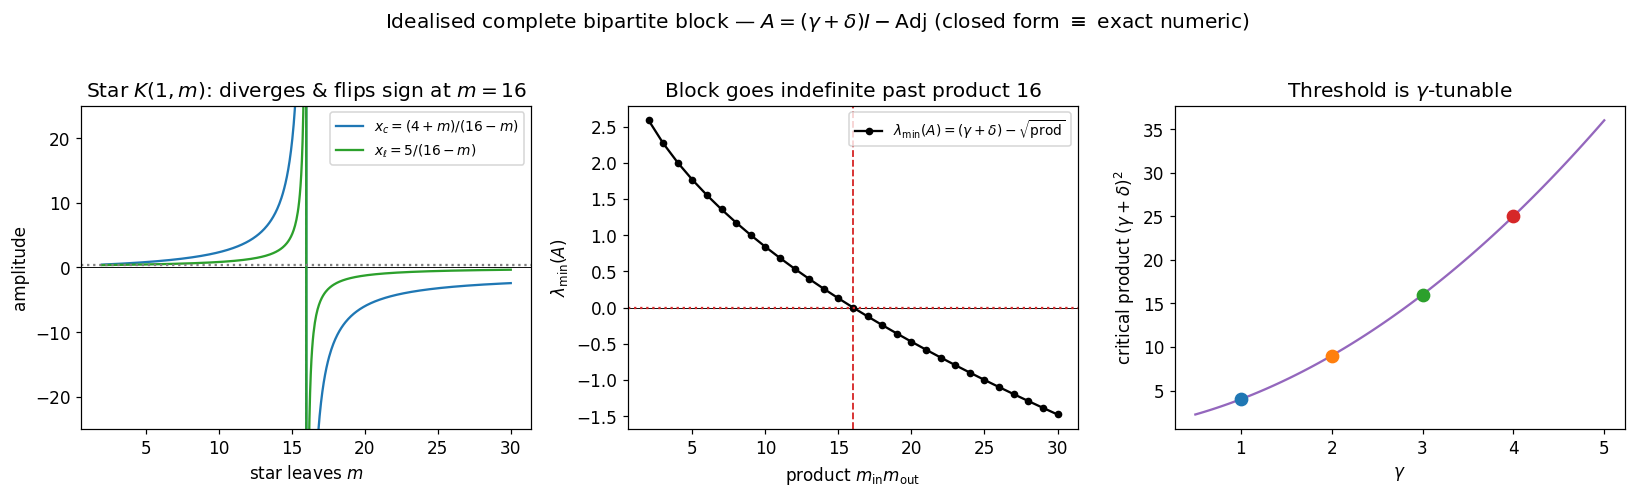

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
mm = np.linspace(2, 30, 600)
ax[0].axhline(0, color="k", lw=.6); ax[0].axvline(16, color="tab:red", ls="--", lw=1.2)
ax[0].plot(mm, (4+mm)/(16-mm), color="tab:blue", label=r"$x_c=(4+m)/(16-m)$")
ax[0].plot(mm, 5/(16-mm), color="tab:green", label=r"$x_\ell=5/(16-m)$")
ax[0].axhline(TAU, color="gray", ls=":"); ax[0].set_ylim(-25, 25)
ax[0].set_xlabel("star leaves $m$"); ax[0].set_ylabel("amplitude")
ax[0].set_title("Star $K(1,m)$: diverges & flips sign at $m=16$"); ax[0].legend(fontsize=9)

prods = np.arange(2, 31)
ax[1].axhline(0, color="k", lw=.6); ax[1].axvline(16, color="tab:red", ls="--", lw=1.2)
ax[1].plot(prods, GD-np.sqrt(prods), "o-", color="k", ms=4, label=r"$\lambda_{\min}(A)=(\gamma+\delta)-\sqrt{\rm prod}$")
ax[1].axhline(0, color="tab:red", ls=":"); ax[1].set_xlabel("product $m_{\\rm in}m_{\\rm out}$")
ax[1].set_ylabel(r"$\lambda_{\min}(A)$"); ax[1].set_title("Block goes indefinite past product 16"); ax[1].legend(fontsize=9)

# how the critical product moves with gamma
gam = np.linspace(0.5, 5, 100)
ax[2].plot(gam, (gam+DELTA)**2, color="tab:purple")
for g in (1,2,3,4): ax[2].plot(g, (g+DELTA)**2, "o", ms=8)
ax[2].set_xlabel(r"$\gamma$"); ax[2].set_ylabel(r"critical product $(\gamma+\delta)^2$")
ax[2].set_title(r"Threshold is $\gamma$-tunable")
fig.suptitle(r"Idealised complete bipartite block — $A=(\gamma+\delta)I-\mathrm{Adj}$ (closed form $\equiv$ exact numeric)", y=1.02)
fig.tight_layout(); fig.savefig(FIG/"01_closed_forms.png", bbox_inches="tight", dpi=140); plt.show()

## 2. A real hub *is* bipartite — and the `eigsh` warning

Build a real event and look at the off-diagonal couplings. For each coupled pair we ask
which hit they share and whether it is `in.end == out.start` (bipartite) or a same-side
collision. **Every** coupled pair is in$\to$out; there are **zero** same-side couplings.
Then we pull out the densest hub, draw its bipartite adjacency $B$, and read its singular
value $\sigma_{\max}(B)$ — the block goes indefinite when $\sigma_{\max}(B)>\gamma+\delta$.

In [5]:
ham, A, Cm, eps, ev = build_A(200, 0.05, 1e-4, seed=11)
seg_hits = np.asarray(ham._segment_to_hit_ids)        # (n,2) [start_hit, end_hit]
coo = A.tocoo(); up = coo.row < coo.col
ri, ci = coo.row[up], coo.col[up]
end_i, start_i = seg_hits[ri,1], seg_hits[ri,0]
end_j, start_j = seg_hits[ci,1], seg_hits[ci,0]
share_ij = end_i == start_j      # i ends at the shared hit, j starts there
share_ji = end_j == start_i
print(f"coupled pairs: {len(ri)}")
print(f"  in->out (i.end==j.start or j.end==i.start): {int((share_ij|share_ji).sum())}  (= ALL)")
print(f"  same in-side (end==end):   {int((end_i==end_j).sum())}   <- 0 expected")
print(f"  same out-side (start==start): {int((start_i==start_j).sum())} <- 0 expected")

# build the per-hub bipartite blocks
mid = np.where(share_ij, end_i, end_j)
hub_in, hub_out, hub_e = defaultdict(set), defaultdict(set), defaultdict(list)
for a, b, h, s in zip(ri, ci, mid, share_ij):
    iseg, oseg = (a, b) if s else (b, a)
    hub_in[h].add(iseg); hub_out[h].add(oseg); hub_e[h].append((iseg, oseg))

def block_sigma(h):
    ins, outs = sorted(hub_in[h]), sorted(hub_out[h])
    di = {s:k for k,s in enumerate(ins)}; do = {s:k for k,s in enumerate(outs)}
    B = np.zeros((len(ins), len(outs)))
    for a,b in hub_e[h]: B[di[a], do[b]] = 1.0
    return B, float(np.linalg.svd(B, compute_uv=False)[0])

# densest hub by sigma_max
best = max(hub_in, key=lambda h: block_sigma(h)[1])
B, smax = block_sigma(best)
print(f"\nDensest hub: m_in={B.shape[0]}, m_out={B.shape[1]}, product={B.shape[0]*B.shape[1]}, "
      f"edges={int(B.sum())} ({100*B.mean():.1f}% filled), sigma_max(B)={smax:.3f}")

coupled pairs: 5449
  in->out (i.end==j.start or j.end==i.start): 5449  (= ALL)
  same in-side (end==end):   0   <- 0 expected
  same out-side (start==start): 0 <- 0 expected

Densest hub: m_in=27, m_out=19, product=513, edges=35 (6.8% filled), sigma_max(B)=3.244


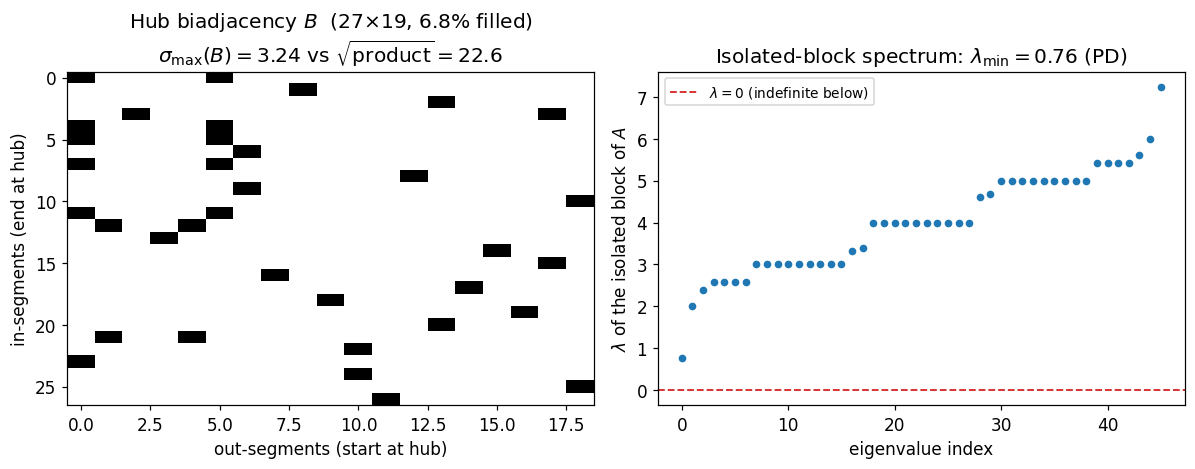

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].imshow(B, aspect="auto", cmap="Greys", interpolation="nearest")
ax[0].set_xlabel("out-segments (start at hub)"); ax[0].set_ylabel("in-segments (end at hub)")
ax[0].set_title(f"Hub biadjacency $B$  ({B.shape[0]}$\\times${B.shape[1]}, "
                f"{100*B.mean():.1f}% filled)\n$\\sigma_{{\\max}}(B)={smax:.2f}$ "
                f"vs $\\sqrt{{\\rm product}}={np.sqrt(B.size):.1f}$")

# spectrum of the isolated block (gamma+delta) I - [[0,B],[B^T,0]]
mi, mo = B.shape
Adj = np.block([[np.zeros((mi,mi)), B], [B.T, np.zeros((mo,mo))]])
ev_blk = np.linalg.eigvalsh(GD*np.eye(mi+mo) - Adj)
ax[1].axhline(0, color="tab:red", ls="--", lw=1.2, label=r"$\lambda=0$ (indefinite below)")
ax[1].plot(ev_blk, "o", ms=4)
ax[1].set_xlabel("eigenvalue index"); ax[1].set_ylabel(r"$\lambda$ of the isolated block of $A$")
ax[1].set_title(f"Isolated-block spectrum: $\\lambda_{{\\min}}={ev_blk.min():.2f}$ "
                f"({'INDEFINITE' if ev_blk.min()<0 else 'PD'})"); ax[1].legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIG/"02_real_hub_bipartite.png", bbox_inches="tight", dpi=140); plt.show()

## 3. The `product > 16` criterion massively *over-predicts*

If the complete-block rule applied, $A$ would be indefinite the moment a hub product
exceeds $(\gamma+\delta)^2=16$ — which happens by $T\sim100$. But real hub blocks are only
a **few % filled**, so $\sigma_{\max}(B)$ grows far more slowly than $\sqrt{\rm product}$ and
barely reaches $\gamma+\delta$. The right per-block test is $\sigma_{\max}(B)>\gamma+\delta$,
and it is only marginally met even at the onset.

T=  50  max hub product=    25  max sigma_max(B)=1.414
T= 100  max hub product=    96  max sigma_max(B)=2.236


T= 200  max hub product=   984  max sigma_max(B)=3.317


T= 400  max hub product=  8784  max sigma_max(B)=3.864


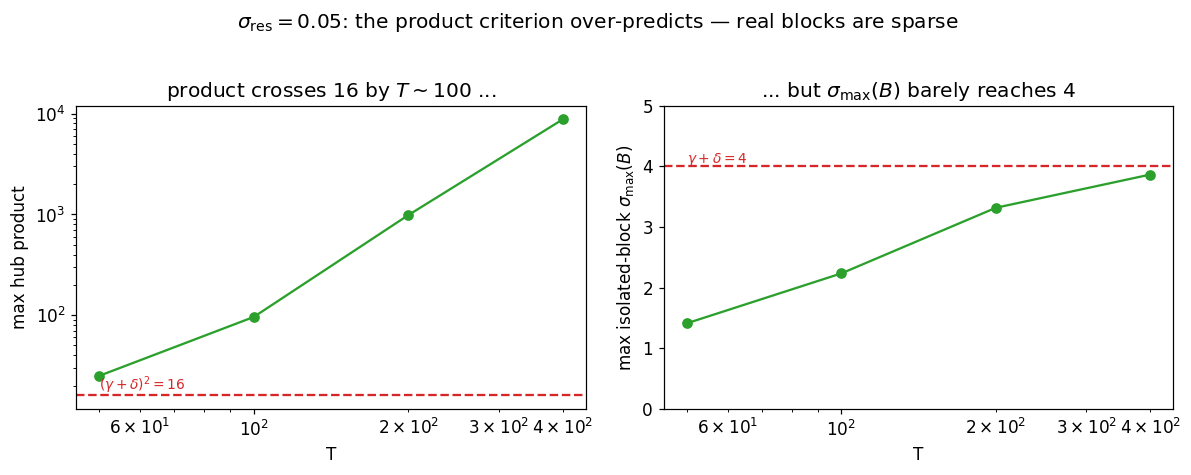

In [7]:
def hub_stats(ham, A):
    sh = np.asarray(ham._segment_to_hit_ids)
    coo = A.tocoo(); up = coo.row < coo.col
    r, c = coo.row[up], coo.col[up]
    sij = sh[r,1] == sh[c,0]; m = np.where(sij, sh[r,1], sh[c,1])
    hi, ho, he = defaultdict(set), defaultdict(set), defaultdict(list)
    for a,b,h,s in zip(r,c,m,sij):
        iseg,oseg = (a,b) if s else (b,a)
        hi[h].add(iseg); ho[h].add(oseg); he[h].append((iseg,oseg))
    max_prod, max_sig = 0, 0.0
    for h in hi:
        ins,outs = sorted(hi[h]), sorted(ho[h]); di={s:k for k,s in enumerate(ins)}; do={s:k for k,s in enumerate(outs)}
        B = np.zeros((len(ins),len(outs)))
        for a,b in he[h]: B[di[a],do[b]] = 1.0
        max_prod = max(max_prod, len(ins)*len(outs))
        max_sig = max(max_sig, float(np.linalg.svd(B, compute_uv=False)[0]) if B.size else 0.0)
    return max_prod, max_sig

Ts = [50, 100, 200, 400]
prod05, sig05 = [], []
for T in Ts:
    ham, A, *_ = build_A(T, 0.05, 1e-4, seed=21)
    p, s = hub_stats(ham, A); prod05.append(p); sig05.append(s)
    print(f"T={T:4d}  max hub product={p:6d}  max sigma_max(B)={s:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].loglog(Ts, prod05, "o-", color="tab:green"); ax[0].axhline(16, color="tab:red", ls="--")
ax[0].text(Ts[0], 18, r"$(\gamma+\delta)^2=16$", color="tab:red", fontsize=9)
ax[0].set_xlabel("T"); ax[0].set_ylabel("max hub product"); ax[0].set_title("product crosses 16 by $T\\sim100$ ...")
ax[1].semilogx(Ts, sig05, "o-", color="tab:green"); ax[1].axhline(GD, color="tab:red", ls="--")
ax[1].text(Ts[0], GD+0.05, r"$\gamma+\delta=4$", color="tab:red", fontsize=9)
ax[1].set_xlabel("T"); ax[1].set_ylabel(r"max isolated-block $\sigma_{\max}(B)$")
ax[1].set_title("... but $\\sigma_{\\max}(B)$ barely reaches 4"); ax[1].set_ylim(0, 5)
fig.suptitle(r"$\sigma_{\rm res}=0.05$: the product criterion over-predicts — real blocks are sparse", y=1.02)
fig.tight_layout(); fig.savefig(FIG/"03_product_overpredicts.png", bbox_inches="tight", dpi=140); plt.show()

## 4. The real instability is **cooperative** — computed *exactly*

The bipartite blocks **share segments**: every segment is an out-segment at the hub at its
start hit and an in-segment at the hub at its end hit. So the blocks chain across the three
interior planes into connected clusters, and the relevant quantity is the **global**
$\lambda_{\max}(C)$, not any single block.

**A computational warning (the gotcha behind §7.12).** A whole-matrix `scipy.sparse.linalg.eigsh`
*silently under-converges* on $C$'s clustered top spectrum at high $T$ and **under-reports** the
maximum — in the §7.12 production grid a `k=48` call returned 4.47 for an event whose exact
$\lambda_{\max}(C)$ was 4.96 (the same matrix scored 4.47 / 4.96 / 5.03 / 6.44 on repeated calls).
We sidestep it entirely: $C$ is a **nonnegative** adjacency matrix and $A$ is block-diagonal over
its connected components, with the heavy eigenvalues all in **small** components — so a
per-component dense eigensolve gives $\lambda_{\max}(C)$ and the exact unstable-mode count,
reproducibly and exactly.

In [8]:
def spectral_C(C, want_vec=False):
    '''EXACT lambda_max(C), n_neg(A)=#{eig(C)>gamma+delta}, top component size, via
    connected-component decomposition (vectorised edge grouping; per-component dense eig).'''
    n = C.shape[0]
    ncomp, lab = connected_components(C, directed=False)
    sizes = np.bincount(lab, minlength=ncomp)
    nodes_order = np.argsort(lab, kind="stable"); lab_sorted = lab[nodes_order]
    first = np.r_[0, np.cumsum(sizes)[:-1]]
    local = np.empty(n, dtype=np.int64); local[nodes_order] = np.arange(n) - first[lab_sorted]
    coo = C.tocoo(); em = coo.row < coo.col; er, ec = coo.row[em], coo.col[em]
    ecomp = lab[er]; eo = np.argsort(ecomp, kind="stable"); er, ec, ecomp = er[eo], ec[eo], ecomp[eo]
    uniq, es = np.unique(ecomp, return_index=True); es = np.r_[es, er.size]
    lmax, nneg, argsz, vcrit, indef = 0.0, 0, 0, None, []
    for j in range(uniq.size):
        uc = int(uniq[j]); s = int(sizes[uc])
        if s < 3: continue
        a, b = es[j], es[j+1]; li, lj = local[er[a:b]], local[ec[a:b]]
        B = np.zeros((s, s)); B[li, lj] = 1.0; B[lj, li] = 1.0
        if want_vec: w, V = np.linalg.eigh(B)
        else:        w = np.linalg.eigvalsh(B); V = None
        m = float(w[-1]); nneg += int((w > GD).sum())
        g = nodes_order[first[uc]:first[uc]+s]
        if m > GD: indef.append(g)
        if m > lmax:
            lmax, argsz = m, s
            if want_vec:
                v = np.zeros(n); v[g] = V[:, -1]; vcrit = v
    cat = np.concatenate(indef) if indef else np.empty(0, dtype=int)
    return dict(lam_max=lmax, n_neg=nneg, top_comp=argsz, max_comp=int(sizes.max()),
                vcrit=vcrit, indef_idx=cat)

# the headline cell, reproducible
ham, A, Cm, eps, ev = build_A(400, 0.05, 1e-4, seed=42)
res = spectral_C(Cm, want_vec=True)
mp, ms = hub_stats(ham, A)
print(f"T=400, sigma_res=0.05, formula eps={eps:.4e}")
print(f"  EXACT  lambda_max(C) = {res['lam_max']:.3f}   -> lambda_min(A) = {GD-res['lam_max']:+.3f}  "
      f"({'INDEFINITE' if res['lam_max']>GD else 'PD'})")
print(f"  best isolated block sigma_max(B) = {ms:.3f}   (cooperative gap = {res['lam_max']-ms:+.3f})")
print(f"  # unstable modes n_neg = {res['n_neg']},  critical component size = {res['top_comp']}")
print(f"  (max connected component = {spectral_C(Cm)['max_comp']} segments — the heavy "
      f"eigenvalues live in SMALL blocks, which is what makes the exact per-component eig cheap)")

T=400, sigma_res=0.05, formula eps=1.5752e-02
  EXACT  lambda_max(C) = 4.114   -> lambda_min(A) = -0.114  (INDEFINITE)
  best isolated block sigma_max(B) = 3.464   (cooperative gap = +0.650)
  # unstable modes n_neg = 2,  critical component size = 92


  (max connected component = 92 segments — the heavy eigenvalues live in SMALL blocks, which is what makes the exact per-component eig cheap)


critical mode: 50% of |v|^2 on 7 segments, 90% on 23 (of 640000); spans 16 distinct hits, planes [0, 1, 2, 3]


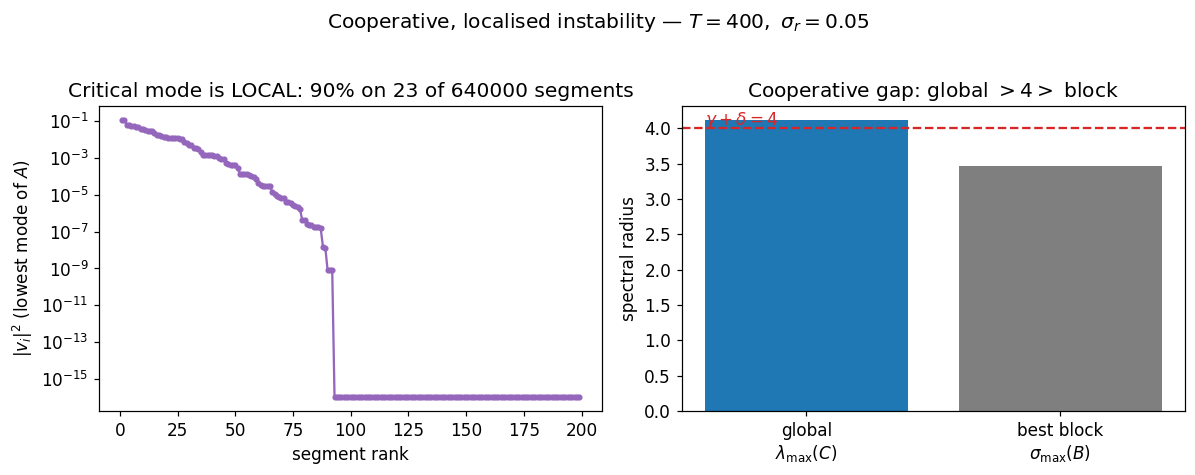

In [9]:
# localise the critical mode
v = res["vcrit"]; p = v**2; order = np.argsort(p)[::-1]
cum = np.cumsum(p[order]); k50 = int(np.searchsorted(cum, .5))+1; k90 = int(np.searchsorted(cum, .9))+1
bnd = ham._group_boundaries; seg_plane = np.zeros(A.shape[0], int)
for gp in range(len(bnd)-1): seg_plane[bnd[gp]:bnd[gp+1]] = gp
supp = order[:k90]
sh = np.asarray(ham._segment_to_hit_ids)
supp_hits = np.unique(np.r_[sh[supp,0], sh[supp,1]])
print(f"critical mode: 50% of |v|^2 on {k50} segments, 90% on {k90} (of {A.shape[0]}); "
      f"spans {len(supp_hits)} distinct hits, planes {sorted(set(int(p) for p in seg_plane[supp]))}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].semilogy(np.arange(1, 200), p[order][:199] + 1e-16, "o-", ms=3, color="tab:purple")
ax[0].set_xlabel("segment rank"); ax[0].set_ylabel(r"$|v_i|^2$ (lowest mode of $A$)")
ax[0].set_title(f"Critical mode is LOCAL: 90% on {k90} of {A.shape[0]} segments")
bars = [res["lam_max"], ms]
ax[1].bar(["global\n$\\lambda_{\\max}(C)$", "best block\n$\\sigma_{\\max}(B)$"], bars,
          color=["tab:blue", "tab:gray"])
ax[1].axhline(GD, color="tab:red", ls="--"); ax[1].text(-.4, GD+.05, r"$\gamma+\delta=4$", color="tab:red")
ax[1].set_ylabel("spectral radius"); ax[1].set_title("Cooperative gap: global $>4>$ block")
fig.suptitle(r"Cooperative, localised instability — $T=400,\ \sigma_r=0.05$", y=1.02)
fig.tight_layout(); fig.savefig(FIG/"04_cooperative_localization.png", bbox_inches="tight", dpi=140); plt.show()

## 5. ... and the classical solve drives the true amplitudes negative

Solve $A x = \delta\mathbf1$ (symmetric-indefinite $\Rightarrow$ MINRES, the method the store
solver uses — CG is invalid here). Plot each segment's amplitude against its weight on the
critical mode: the true segments sitting on the critical cluster are pushed **below $\tau$ and
negative**, which is exactly the efficiency loss — no threshold can recover them.

classical solve: MINRES info=0; segment efficiency at tau=0.35 = 0.984
  true segments below tau: 1.6%   |   true segments < 0: 1.50%


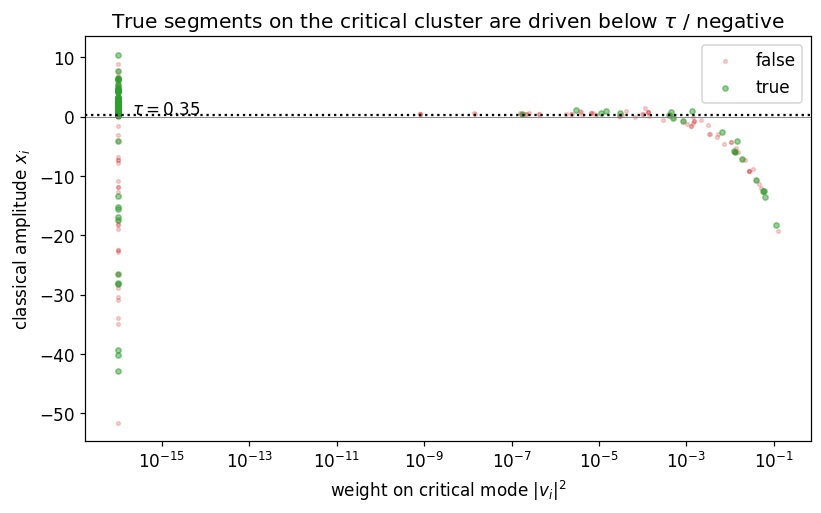

In [10]:
truth = segment_truth_mask(ham)
b = DELTA * np.ones(A.shape[0])
x, info = spla.minres(A, b, rtol=1e-8, maxiter=5000)
mass = res["vcrit"]**2
eff035 = (x[truth] > TAU).mean()
print(f"classical solve: MINRES info={info}; segment efficiency at tau=0.35 = {eff035:.3f}")
print(f"  true segments below tau: {(x[truth]<TAU).mean()*100:.1f}%   |   true segments < 0: {(x[truth]<0).mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.scatter(mass[~truth]+1e-16, x[~truth], s=6, alpha=.2, color="tab:red", label="false")
ax.scatter(mass[truth]+1e-16, x[truth], s=12, alpha=.5, color="tab:green", label="true")
ax.axhline(TAU, color="k", ls=":"); ax.text(2e-16, TAU+.05, r"$\tau=0.35$")
ax.axhline(0, color="gray", lw=.6); ax.set_xscale("log")
ax.set_xlabel(r"weight on critical mode $|v_i|^2$"); ax.set_ylabel("classical amplitude $x_i$")
ax.set_title(r"True segments on the critical cluster are driven below $\tau$ / negative")
ax.legend(); fig.tight_layout(); fig.savefig(FIG/"05_amplitudes_corrupted.png", bbox_inches="tight", dpi=140); plt.show()

## 6. The $(\sigma_{\rm res}, T)$ boundary

Sweep $\lambda_{\max}(C)$ over a small grid (formula $\varepsilon$, $\sigma_{\rm scatt}=10^{-4}$,
2 reproducible reps). Only $\sigma_{\rm res}=0.05$ pierces $\gamma+\delta=4$, near $T_c\approx290$
— exactly where the measured classical efficiency cliffs. $\sigma_{\rm res}\le0.02$ stays PD and
efficiency stays $\approx1$. (§7.12 runs this to $T=1000$ over 3 reps and overlays the store
efficiency heatmap.)

sigma_res=0.0: lambda_max(C) = 1.62, 1.62, 1.73, 1.92


sigma_res=0.01: lambda_max(C) = 1.73, 2.62, 2.93, 2.87


sigma_res=0.02: lambda_max(C) = 2.06, 3.48, 3.76, 3.48


sigma_res=0.05: lambda_max(C) = 2.95, 4.62, 5.96, 5.31


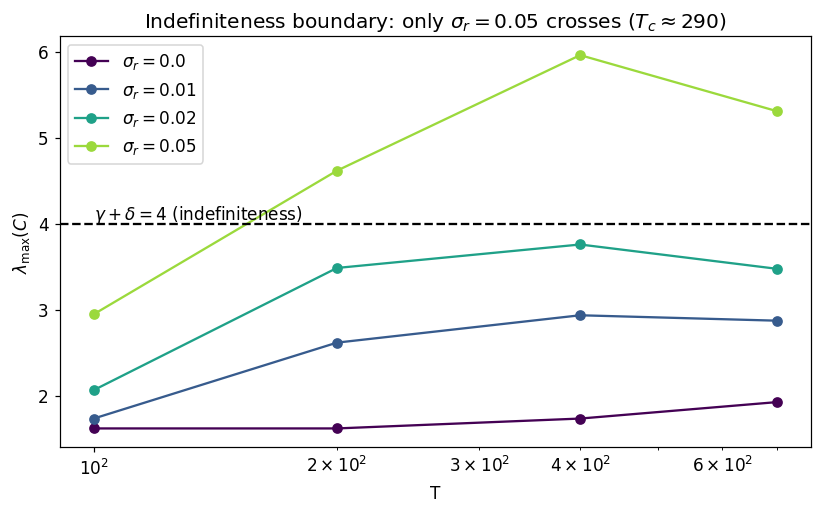

In [11]:
SR = [0.0, 0.01, 0.02, 0.05]; TS = [100, 200, 400, 700]; NREP = 2
lam = {sr: [] for sr in SR}
for sr in SR:
    for T in TS:
        vals = []
        for rep in range(NREP):
            _, _, Cc, _, _ = build_A(T, sr, 1e-4, seed=1000 + T*7 + rep)
            vals.append(spectral_C(Cc)["lam_max"])
        lam[sr].append(np.mean(vals))
    print(f"sigma_res={sr}: lambda_max(C) = " + ", ".join(f"{v:.2f}" for v in lam[sr]))

fig, ax = plt.subplots(figsize=(7.6, 4.8))
cols = plt.cm.viridis(np.linspace(0, .85, len(SR)))
for sr, c in zip(SR, cols):
    ax.plot(TS, lam[sr], "o-", color=c, label=f"$\\sigma_r={sr}$")
ax.axhline(GD, color="k", ls="--"); ax.text(TS[0], GD+.05, r"$\gamma+\delta=4$ (indefiniteness)")
ax.set_xscale("log"); ax.set_xlabel("T"); ax.set_ylabel(r"$\lambda_{\max}(C)$")
ax.set_title(r"Indefiniteness boundary: only $\sigma_r=0.05$ crosses ($T_c\approx290$)")
ax.legend(); fig.tight_layout(); fig.savefig(FIG/"06_boundary.png", bbox_inches="tight", dpi=140); plt.show()

## 7. The two fixes

$A$ is indefinite because $\lambda_{\max}(C)$ overtook the diagonal $\gamma+\delta$. Two levers:

1. **Raise $\gamma$** — lift the diagonal. PD is restored for $\gamma>\lambda_{\max}(C)-\delta$.
   The $\gamma$-aware threshold $\tau=\delta/(\delta+\gamma)+0.10$ simply shifts down with it.
2. **Tighten $\varepsilon$** — thin the coupling, lowering $\lambda_{\max}(C)$, but at the cost of
   true-coupling efficiency (the §7.3 knee / §7.7 ROC).

At fixed efficiency the $\gamma$-bump is the cleaner lever: it moves the *threshold*, not the
*signal*.

fixed event lambda_max(C)=4.114  ->  gamma* = 3.11 (need gamma>3.11 for PD)
lambda_max(C) vs eps/eps_formula: ['3.37', '3.55', '3.78', '3.97', '4.11', '4.78', '5.29']


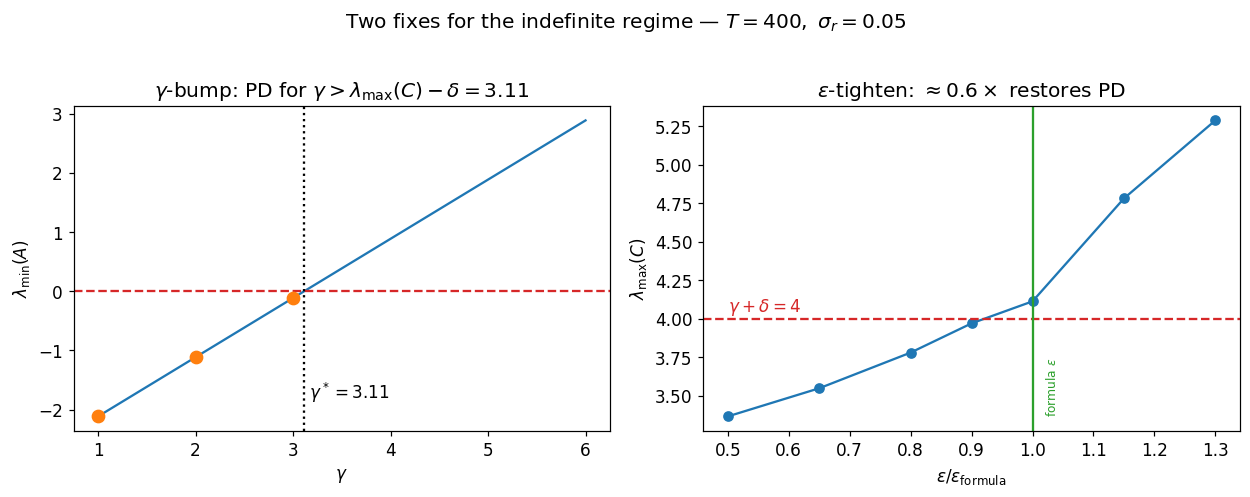

In [12]:
# one fixed indefinite event, used for both panels
ev6 = gen_event(400, 0.05, 1e-4, seed=42)
_, _, C6, eps6, _ = build_A(400, 0.05, 1e-4, seed=0, ev=ev6)
lmax6 = spectral_C(C6)["lam_max"]
gammas = np.linspace(1, 6, 60); lam_min_vs_g = (gammas + DELTA) - lmax6
gstar = lmax6 - DELTA

mults = [0.5, 0.65, 0.8, 0.9, 1.0, 1.15, 1.3]; lam_vs_eps = []
for mu in mults:
    _, _, Cx, _, _ = build_A(400, 0.05, 1e-4, seed=0, ev=ev6, eps=eps6*mu)
    lam_vs_eps.append(spectral_C(Cx)["lam_max"])
print(f"fixed event lambda_max(C)={lmax6:.3f}  ->  gamma* = {gstar:.2f} (need gamma>{gstar:.2f} for PD)")
print("lambda_max(C) vs eps/eps_formula:", [f"{v:.2f}" for v in lam_vs_eps])

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax[0].plot(gammas, lam_min_vs_g, color="tab:blue"); ax[0].axhline(0, color="tab:red", ls="--")
ax[0].axvline(gstar, color="k", ls=":"); ax[0].text(gstar+.05, lam_min_vs_g.min()+.3, f"$\\gamma^*={gstar:.2f}$")
for g in (1,2,3): ax[0].plot(g, (g+DELTA)-lmax6, "o", ms=8, color="tab:orange" if (g+DELTA)<lmax6 else "tab:green")
ax[0].set_xlabel(r"$\gamma$"); ax[0].set_ylabel(r"$\lambda_{\min}(A)$")
ax[0].set_title(f"$\\gamma$-bump: PD for $\\gamma>\\lambda_{{\\max}}(C)-\\delta={gstar:.2f}$")
ax[1].plot(mults, lam_vs_eps, "o-", color="tab:blue"); ax[1].axhline(GD, color="tab:red", ls="--")
ax[1].axvline(1.0, color="tab:green"); ax[1].text(1.02, min(lam_vs_eps), "formula $\\varepsilon$", rotation=90, va="bottom", color="tab:green", fontsize=8)
ax[1].text(mults[0], GD+.05, r"$\gamma+\delta=4$", color="tab:red")
ax[1].set_xlabel(r"$\varepsilon/\varepsilon_{\rm formula}$"); ax[1].set_ylabel(r"$\lambda_{\max}(C)$")
ax[1].set_title(r"$\varepsilon$-tighten: $\approx0.6\times$ restores PD")
fig.suptitle(r"Two fixes for the indefinite regime — $T=400,\ \sigma_r=0.05$", y=1.02)
fig.tight_layout(); fig.savefig(FIG/"07_fixes.png", bbox_inches="tight", dpi=140); plt.show()

## Summary

- $A=(\gamma+\delta)I-C$ is **indefinite $\iff \lambda_{\max}(C)>\gamma+\delta$**.
- A hub is a **bipartite** block $K(m_{\rm in},m_{\rm out})$ (verified: 0 same-side couplings); its
  complete-block limit goes singular at product $(\gamma+\delta)^2=16$ — but **real blocks are
  sparse**, so the `product>16` criterion over-predicts and isolated hubs barely break.
- The true instability is **cooperative**: chained bipartite blocks push the *global*
  $\lambda_{\max}(C)$ past $\gamma+\delta$ on a **localised multi-hub cluster**, driving the true
  amplitudes there negative. Computed **exactly** by connected-component decomposition (a
  whole-matrix `eigsh` under-converges — shown live above).
- The $(\sigma_{\rm res},T)$ crossing ($T_c\approx290$ at $\sigma_r=0.05$; PD for $\sigma_r\le0.02$)
  **reproduces the measured classical efficiency cliff**, and is distinct from the purity collapse.
- **Fix** by raising $\gamma$ above $\lambda_{\max}(C)-\delta$ (cleaner) or tightening $\varepsilon$.

For the full production treatment — the $T\le1000$ grid, the exact unstable-mode count
$n_{\rm neg}$ tracking the cliff depth ($3\to118\to1600$), the store-backed localisation
(100% of lost-true on indefinite clusters, $\sim4660\times$ lift), and the 1BQF
$f(\lambda)=\cos(\lambda t/2)$ sign-blindness — see **Epsilon_study_2 §7.12** and
`gen_indefiniteness_study.py`.